# 🚨 RetailPulse — Anomaly Detection
## Objective
Detect unusual months where actual sales deviated 
significantly from expected patterns using statistical thresholds.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Loading cleaned dataset
df = pd.read_csv('../data/superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Creating monthly sales time series
monthly_sales = df.groupby('Month_Year')['Sales'].sum()
monthly_sales.index = pd.PeriodIndex(monthly_sales.index, freq='M')
monthly_sales = monthly_sales.sort_index()
monthly_sales.index = monthly_sales.index.to_timestamp()

print("✅ Data loaded successfully!")
print("Shape:", monthly_sales.shape)

✅ Data loaded successfully!
Shape: (48,)


## 1. Calculating Rolling Statistics
Computing rolling mean and standard deviation 
to establish normal sales behavior.

In [2]:
# Using simple mean and std for anomaly detection
mean_sales = monthly_sales.mean()
std_sales = monthly_sales.std()

upper_threshold = mean_sales + (2 * std_sales)
lower_threshold = mean_sales - (2 * std_sales)

print("Anomaly Thresholds:")
print("=" * 40)
print(f"Mean Sales   : ${mean_sales:,.0f}")
print(f"Upper Limit  : ${upper_threshold:,.0f}")
print(f"Lower Limit  : ${lower_threshold:,.0f}")

Anomaly Thresholds:
Mean Sales   : $47,858
Upper Limit  : $98,250
Lower Limit  : $-2,533


## 2. Detecting Anomalies
Flagging months where sales crossed upper or lower thresholds.

In [3]:
# Flagging anomalies
anomalies = monthly_sales[
    (monthly_sales > upper_threshold) | 
    (monthly_sales < lower_threshold)
]

print("🚨 Anomaly Months Detected:")
print("=" * 45)
if len(anomalies) == 0:
    print("No anomalies detected!")
else:
    for date, value in anomalies.items():
        print(f"{date.strftime('%B %Y')} → ${value:,.0f}")

print(f"\nTotal anomalies: {len(anomalies)}")

🚨 Anomaly Months Detected:
November 2017 → $118,448

Total anomalies: 1


## 3. Anomaly Visualization
Plotting sales with anomaly points highlighted.

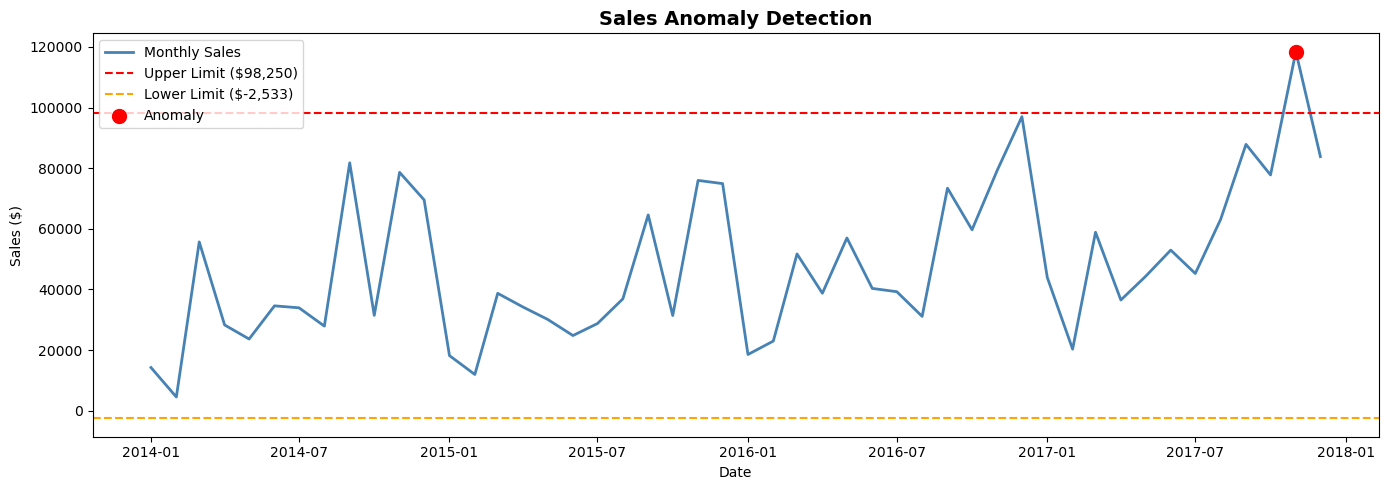

In [4]:
# Plotting anomalies
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index, monthly_sales, 
         color='steelblue', label='Monthly Sales', linewidth=2)
plt.axhline(y=upper_threshold, color='red', 
            linestyle='--', label=f'Upper Limit (${upper_threshold:,.0f})')
plt.axhline(y=lower_threshold, color='orange', 
            linestyle='--', label=f'Lower Limit (${lower_threshold:,.0f})')
plt.scatter(anomalies.index, anomalies.values, 
            color='red', s=100, zorder=5, label='Anomaly')
plt.title('Sales Anomaly Detection', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Key Findings
Summary of anomaly detection analysis.

In [5]:
print("Key Findings — Anomaly Detection:")
print("=" * 45)
print(f"Total months analyzed : 48")
print(f"Normal range          : ${lower_threshold:,.0f} to ${upper_threshold:,.0f}")
print(f"Anomalies detected    : {len(anomalies)}")
print("-" * 45)
print("🚨 Anomaly Month:")
print("November 2017 → $118,448")
print("→ 20.5% above upper threshold!")
print("→ Possible reason: Holiday season + Black Friday")
print("→ Business action: Replicate this strategy!")

Key Findings — Anomaly Detection:
Total months analyzed : 48
Normal range          : $-2,533 to $98,250
Anomalies detected    : 1
---------------------------------------------
🚨 Anomaly Month:
November 2017 → $118,448
→ 20.5% above upper threshold!
→ Possible reason: Holiday season + Black Friday
→ Business action: Replicate this strategy!
